In [1]:
import sqlite3
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

conn = sqlite3.connect("../retailiq.db")
df = pd.read_sql("SELECT * FROM customer_features", conn)
conn.close()

print(df.shape)
print(df.dtypes)
df.head()

(93397, 20)
customer_unique_id          object
recency_days               float64
frequency                    int64
monetary                   float64
r_score                      int64
f_score                      int64
m_score                      int64
rfm_total                    int64
segment                     object
repeat_order_count         float64
avg_days_between_orders    float64
min_days_between_orders    float64
max_days_between_orders    float64
avg_review_score           float64
review_count               float64
avg_delivery_days          float64
avg_delay_days             float64
customer_state              object
churned                      int64
treatment_voucher          float64
dtype: object


,customer_unique_id,recency_days,frequency,monetary,r_score,f_score,m_score,rfm_total,segment,repeat_order_count,avg_days_between_orders,min_days_between_orders,max_days_between_orders,avg_review_score,review_count,avg_delivery_days,avg_delay_days,customer_state,churned,treatment_voucher
0,5d15c22ab8b1efd3c7ec3253f3531299,114.0,1,398.46,4,4,4,12,Champions,0.0,-1.0,NaN,NaN,4.0,1.0,31.101898,-3.171725,RN,1,0.0
1,88da21ad308ca9bff370909f980da689,114.0,1,217.04,4,4,4,12,Champions,0.0,-1.0,NaN,NaN,5.0,1.0,10.035729,-5.232199,SP,1,0.0
2,7bbcad674e8c0ed95d070049efee7646,114.0,1,963.34,4,4,4,12,Champions,0.0,-1.0,NaN,NaN,1.0,1.0,7.777164,-8.489699,ES,1,0.0
3,d2f79db37031301a54d560415cadac21,114.0,1,413.77,4,4,4,12,Champions,0.0,-1.0,NaN,NaN,4.0,1.0,13.998368,-13.221319,ES,1,0.0
4,d242c2a33b19c5fab2ccf4f67dcaba86,114.0,1,397.70,4,4,4,12,Champions,0.0,-1.0,NaN,NaN,5.0,1.0,6.959757,-14.250938,SP,1,0.0


In [2]:
# Target: monetary (total spend) -- this IS our CLV proxy for this dataset
# (most customers are one-time buyers, so historical spend is the most honest
# CLV signal we have without multi-year repeat data)

target = "monetary"

feature_cols = [
    "recency_days", "frequency", "repeat_order_count",
    "avg_days_between_orders", "avg_review_score", "review_count",
    "avg_delivery_days", "avg_delay_days"
]

model_df = df[feature_cols + [target]].dropna()
print(f"Rows available for modeling: {model_df.shape[0]} (dropped {df.shape[0] - model_df.shape[0]})")

X = model_df[feature_cols]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Rows available for modeling: 92786 (dropped 611)
Train: (74228, 8), Test: (18558, 8)


In [3]:
model = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)

print(f"MAE: {round(mae, 2)}")
print(f"R²: {round(r2, 3)}")

# Baseline comparison: what if we just predicted the mean for everyone?
baseline_preds = [y_train.mean()] * len(y_test)
baseline_mae = mean_absolute_error(y_test, baseline_preds)
print(f"\nBaseline (mean) MAE: {round(baseline_mae, 2)}")
print(f"Improvement over baseline: {round(100*(baseline_mae-mae)/baseline_mae, 1)}%")

MAE: 110.72
R²: 0.028

Baseline (mean) MAE: 114.09
Improvement over baseline: 2.9%


avg_delay_days             0.403090
avg_delivery_days          0.262719
recency_days               0.200089
avg_days_between_orders    0.036956
frequency                  0.035850
repeat_order_count         0.035298
avg_review_score           0.024092
review_count               0.001905
dtype: float64


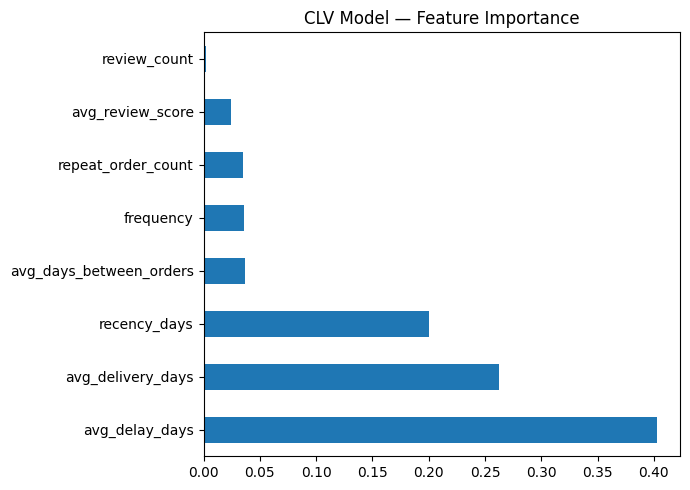

In [4]:
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importances)

import matplotlib.pyplot as plt
importances.plot(kind="barh", figsize=(7,5), title="CLV Model — Feature Importance")
plt.tight_layout()
plt.show()

In [5]:
import joblib
joblib.dump(model, "../models_clv.pkl")
print("Model saved")

Model saved
